In [ ]:
##_____EDA_____

In [ ]:
!pip install numpy==1.26.4 # specific version of numpy library

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 28.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [ ]:
import numpy as np
print ("Numpy version:", np.__version__)

Numpy version: 1.26.4


In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sriharshaeedala/financial-fraud-detection-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sudeshnadass
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sriharshaeedala/financial-fraud-detection-dataset


100%|██████████| 178M/178M [00:00<00:00, 836MB/s] 


In [ ]:
import pandas as pd
df = pd.read_csv("/content/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
print(df.shape)

(6362620, 11)


In [ ]:
print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [ ]:
print(df.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [ ]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
#Count of fraudulent vs non-fraudulent transactions
fraud_counts = df['isFraud'].value_counts()
print(fraud_counts[0])
print(fraud_counts[1])

6354407
8213


In [ ]:
fraud_percent = (fraud_counts[1] / len(df)) * 100
print(f"\n⚠️ Fraudulent Transactions Percentage: {fraud_percent:.4f}%")



⚠️ Fraudulent Transactions Percentage: 0.1291%


/tmp/ipython-input-13-2344509411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df, palette={'0': 'skyblue', '1': 'salmon'})


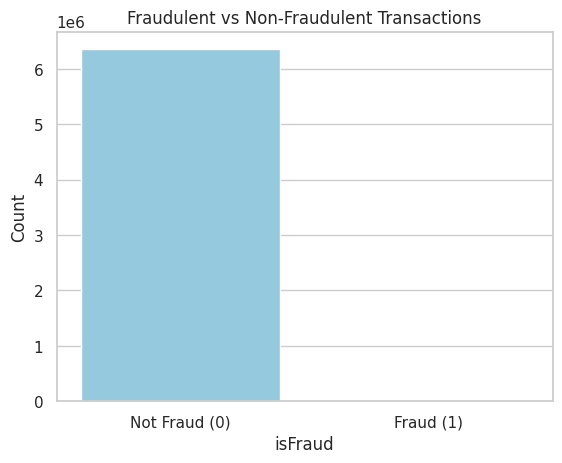

In [ ]:
# Bar chart
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='isFraud', data=df, palette={'0': 'skyblue', '1': 'salmon'})
plt.xticks([0, 1], ['Not Fraud (0)', 'Fraud (1)'])
plt.title("Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()

In [ ]:
# Count of transaction types
print(df['type'].value_counts())


type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


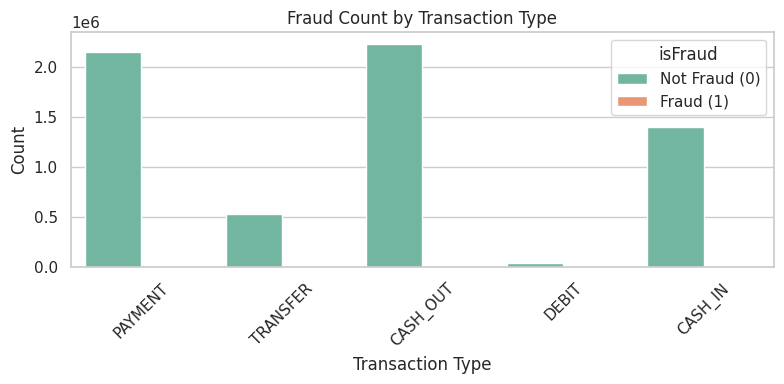

In [ ]:
#Visualize fraud distribution by transaction type
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='type', hue='isFraud', palette='Set2')
plt.title("Fraud Count by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title='isFraud', labels=['Not Fraud (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

/tmp/ipython-input-16-2778102675.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df, palette={'0': 'skyblue', '1': 'salmon'})


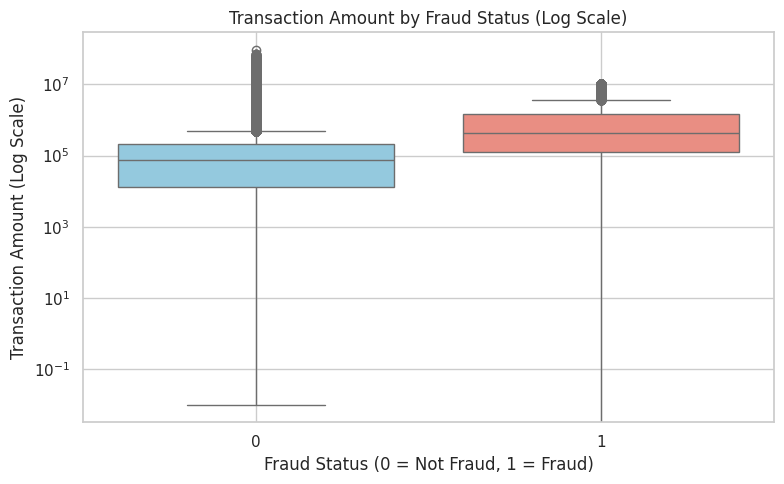

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Boxplot to show amount distribution by fraud status
plt.figure(figsize=(8,5))
sns.boxplot(x='isFraud', y='amount', data=df, palette={'0': 'skyblue', '1': 'salmon'})
plt.yscale('log')  # log scale helps handle extreme outliers
plt.title("Transaction Amount by Fraud Status (Log Scale)")
plt.xlabel("Fraud Status (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount (Log Scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

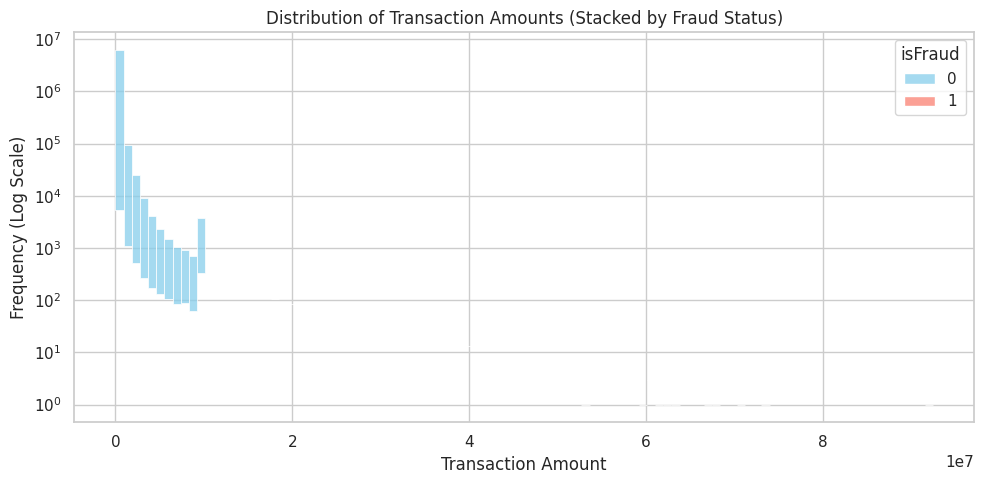

In [ ]:
#Histogram for visual comparison
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='amount', bins=100, hue='isFraud', multiple='stack', palette={0: 'skyblue', 1: 'salmon'}, log_scale=(False, True))
plt.title("Distribution of Transaction Amounts (Stacked by Fraud Status)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency (Log Scale)")
plt.tight_layout()
plt.show()

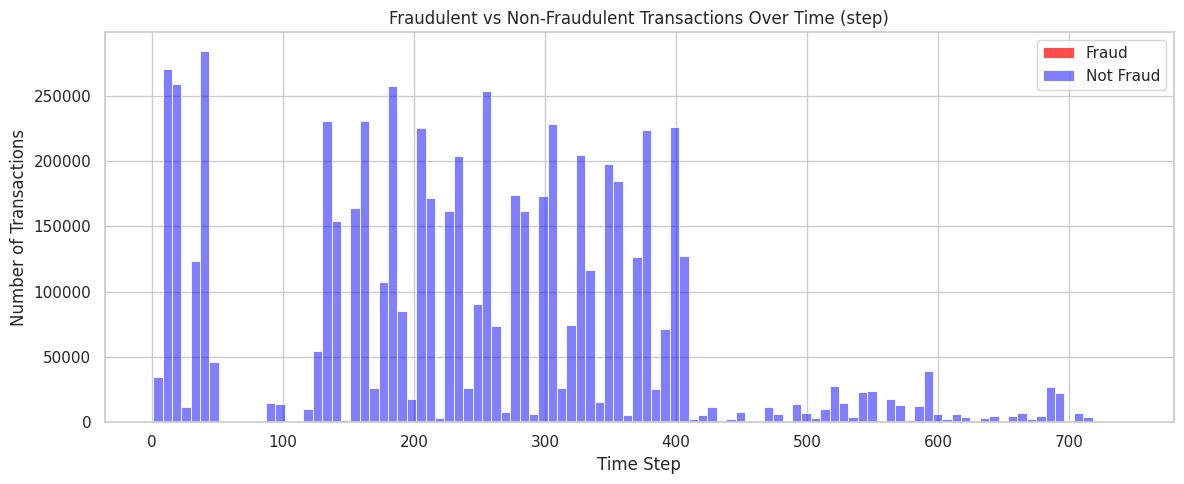

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Check time-based distribution using 'step'
plt.figure(figsize=(12,5))
sns.histplot(data=df[df['isFraud'] == 1], x='step', bins=100, color='red', label='Fraud', alpha=0.7)
sns.histplot(data=df[df['isFraud'] == 0], x='step', bins=100, color='blue', label='Not Fraud', alpha=0.5)
plt.title("Fraudulent vs Non-Fraudulent Transactions Over Time (step)")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Top 10 sender accounts involved in fraud
fraud_origins = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)
print(fraud_origins)


nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64


In [ ]:

#Top 10 receiver accounts involved in fraud
fraud_destinations = df[df['isFraud'] == 1]['nameDest'].value_counts().head(10)
print(fraud_destinations)

nameDest
C1193568854    2
C104038589     2
C200064275     2
C1497532505    2
C1601170327    2
C1655359478    2
C2020337583    2
C1653587362    2
C1013511446    2
C2129197098    2
Name: count, dtype: int64


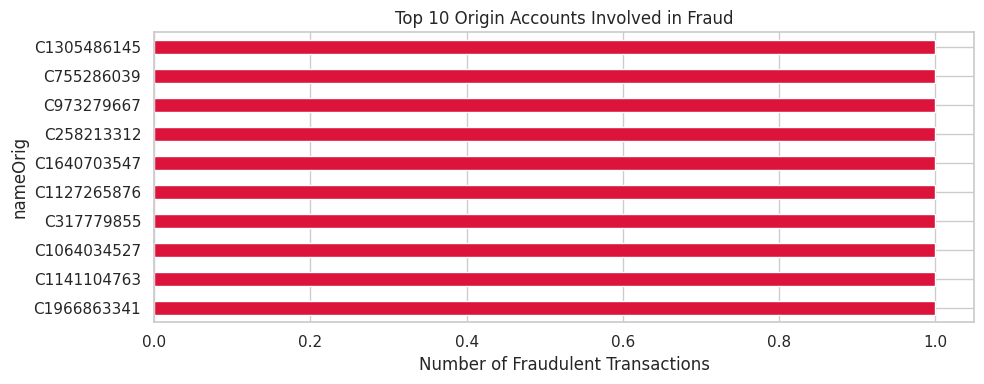

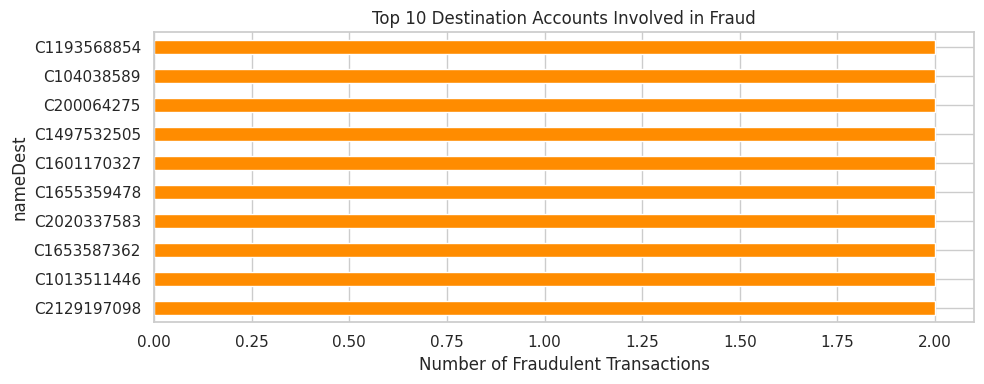

In [ ]:
#visualize as bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
fraud_origins.plot(kind='barh', color='crimson')
plt.title("Top 10 Origin Accounts Involved in Fraud")
plt.xlabel("Number of Fraudulent Transactions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
fraud_destinations.plot(kind='barh', color='darkorange')
plt.title("Top 10 Destination Accounts Involved in Fraud")
plt.xlabel("Number of Fraudulent Transactions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


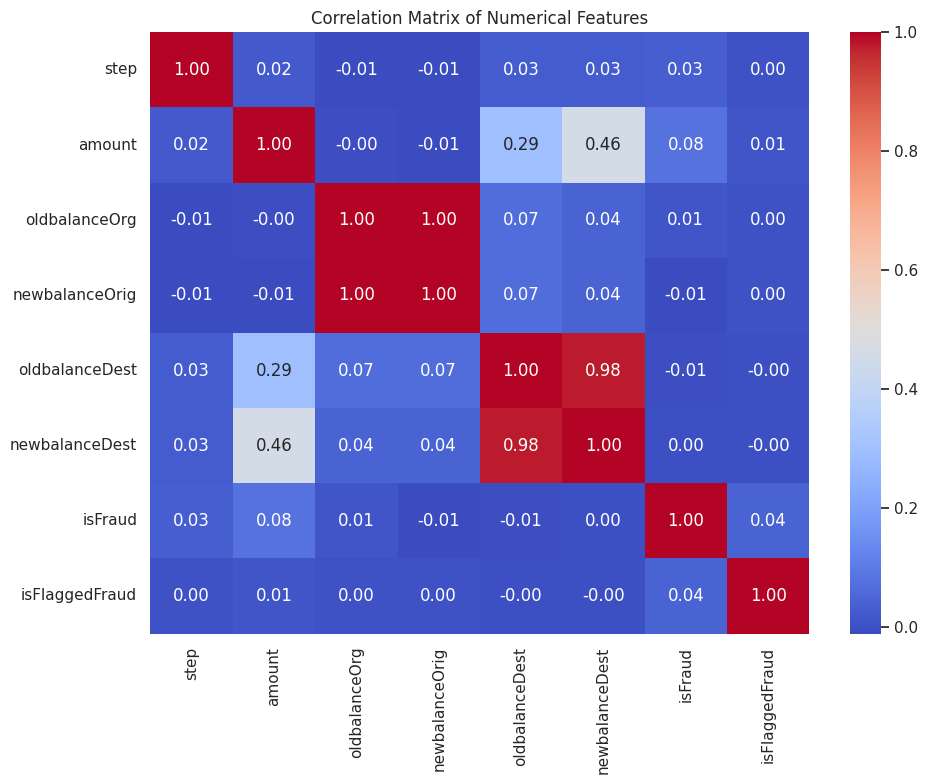

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns before computing correlation matrix
numerical_df = df.select_dtypes(include=[np.number])
corr = numerical_df.corr()

# Display the correlation matrix (optional, but helpful)
display(corr)

# You can then proceed to visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

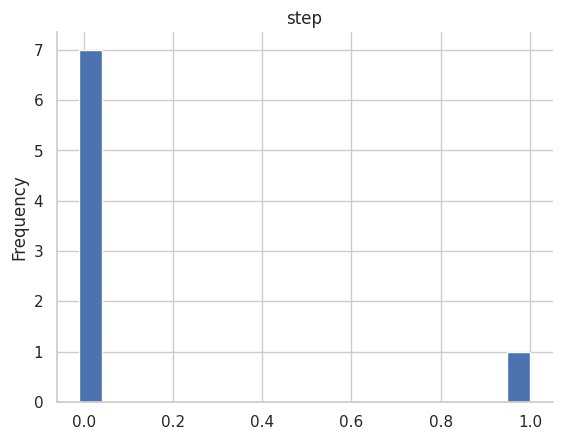

In [ ]:
#title step

from matplotlib import pyplot as plt
corr['step'].plot(kind='hist', bins=20, title='step')
plt.gca().spines[['top', 'right',]].set_visible(False)

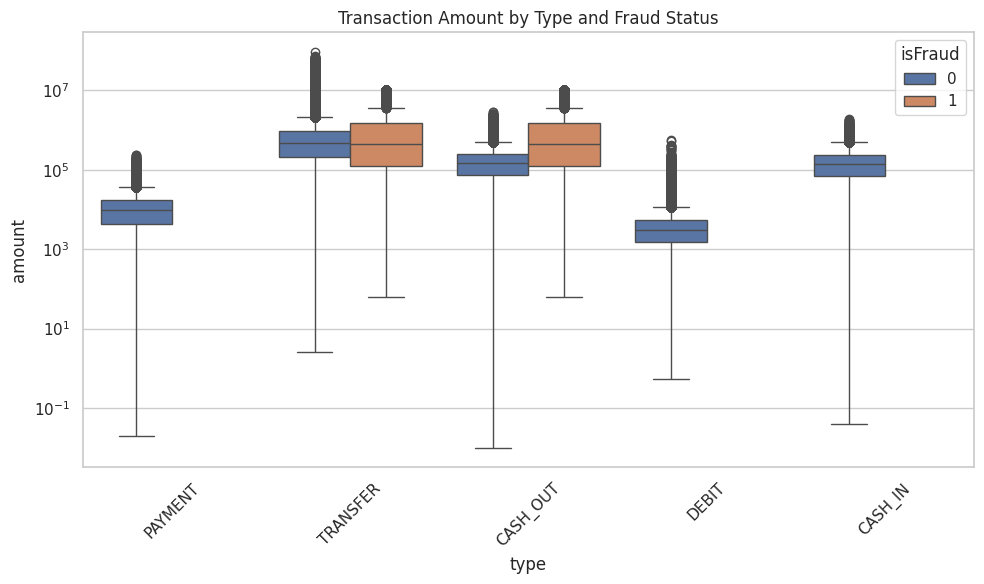

In [ ]:
#Transaction Amount by Type & Fraud
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['amount'] > 0], x='type', y='amount', hue='isFraud')
plt.yscale('log')
plt.title("Transaction Amount by Type and Fraud Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

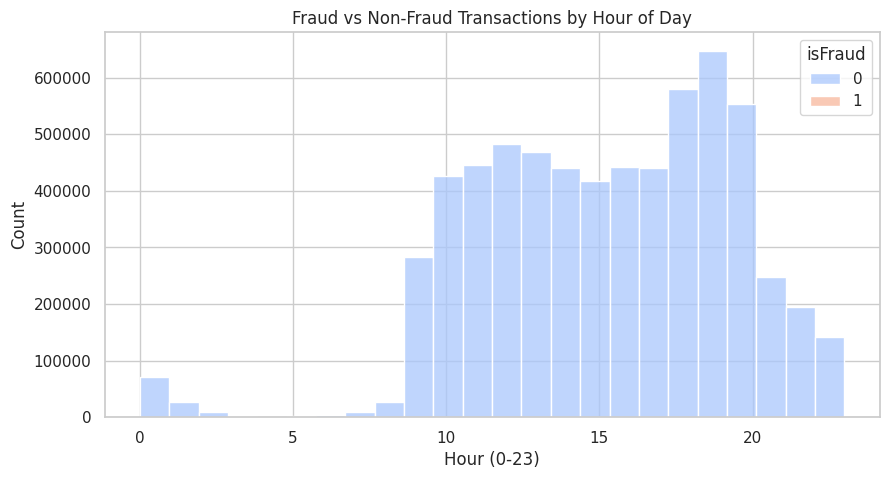

In [ ]:
#Hourly Pattern of Fraud
df['hour'] = df['step'] % 24

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='hour', hue='isFraud', multiple='stack', bins=24, palette='coolwarm')
plt.title("Fraud vs Non-Fraud Transactions by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Count")
plt.show()

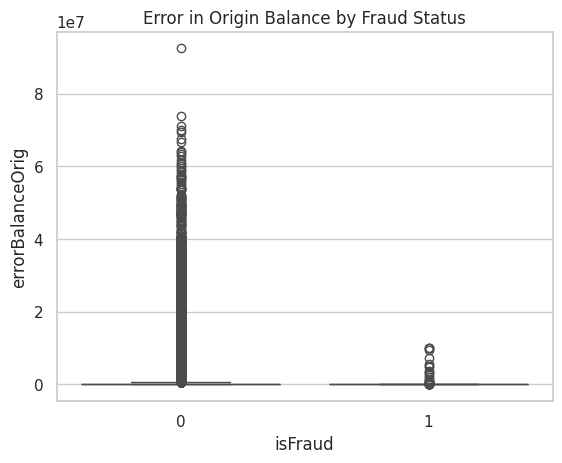

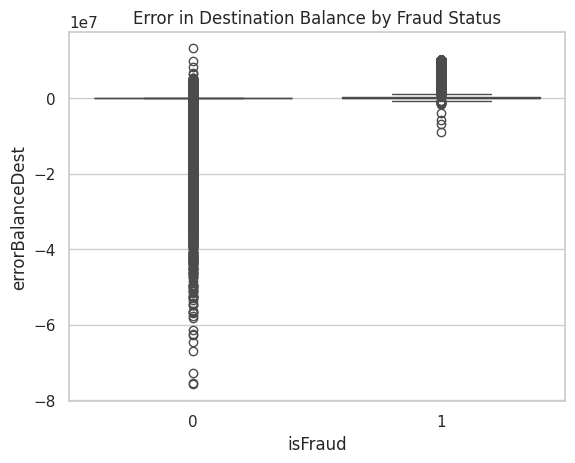

In [ ]:
#Balance Analysis Before & After Transaction
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

sns.boxplot(x='isFraud', y='errorBalanceOrig', data=df)
plt.title("Error in Origin Balance by Fraud Status")
plt.show()

sns.boxplot(x='isFraud', y='errorBalanceDest', data=df)
plt.title("Error in Destination Balance by Fraud Status")
plt.show()

In [ ]:
#High-Amount Frauds Detection
high_value_frauds = df[(df['isFraud'] == 1) & (df['amount'] > 1e6)]
print("High-value frauds:\n", high_value_frauds[['type', 'amount', 'nameOrig', 'nameDest']].head())

High-value frauds:
           type       amount     nameOrig     nameDest
969   TRANSFER   1277212.77  C1334405552   C431687661
970   CASH_OUT   1277212.77   C467632528   C716083600
3059  TRANSFER   1096187.24  C1093223281  C2063275841
3060  CASH_OUT   1096187.24    C77163673   C644345897
4440  TRANSFER  10000000.00     C7162498   C945327594


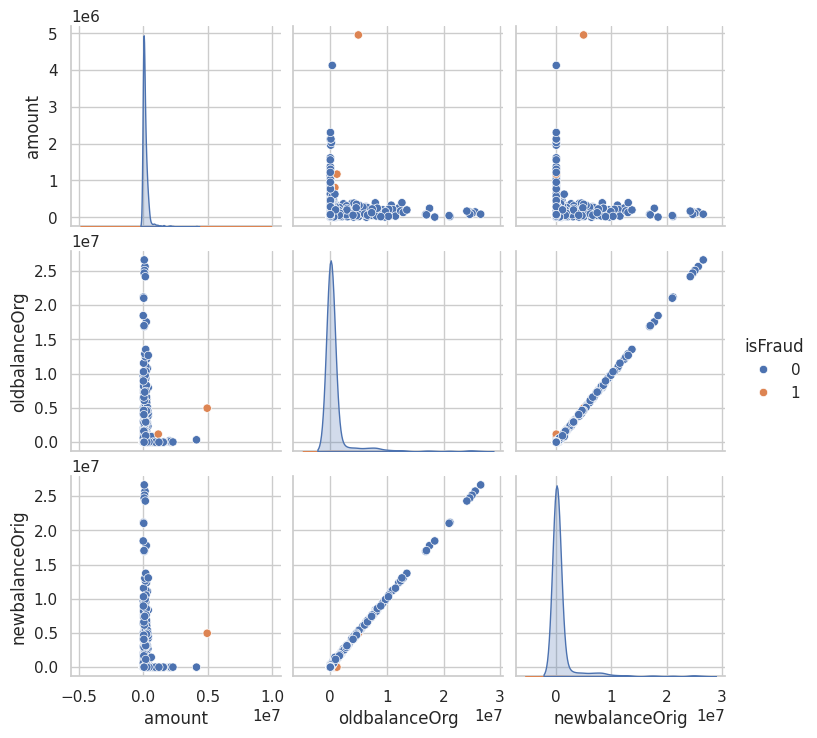

In [ ]:
#Pairplot of Key Features
import seaborn as sns
sample_df = df.sample(1000, random_state=42)  # Limit for performance
sns.pairplot(sample_df, hue='isFraud', vars=['amount', 'oldbalanceOrg', 'newbalanceOrig'])
plt.show()

In [ ]:
##______Feature Engineering + Model Training________

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
# Copy to avoid changing original
data = df.copy()

In [ ]:
# --- Feature Engineering ---

# Convert 'step' to datetime (assuming step represents time in some unit, e.g., hours)
# Note: The dataset documentation would clarify the unit of 'step'.
# For now, we'll treat 'step' as hours and convert to a timedelta from a reference point
data['transaction_time'] = pd.to_timedelta(data['step'], unit='h')

In [ ]:
# Extract time-based features
data['transaction_hour'] = data['transaction_time'].dt.components.hours
data['transaction_day'] = data['transaction_time'].dt.days

In [ ]:
# High-value transaction flag (top 5% amounts)
data['is_large_amount'] = (data['amount'] > data['amount'].quantile(0.95)).astype(int)

In [ ]:
# --- Handle Categorical Variables ---
categorical_cols = ['transaction_type', 'device_type', 'merchant']  # Replace with actual categorical columns
le = LabelEncoder()

In [ ]:
# --- Handle Categorical Variables ---
# One-Hot Encode the 'type' column
X = pd.get_dummies(X, columns=['type'], drop_first=True)

In [ ]:
# --- Drop Unnecessary Columns ---
# Drop columns that are not needed for training. We'll keep 'nameOrig' and 'nameDest' for now,
# as they might be useful for graph-based analysis later, but drop IDs and the original time column.
drop_cols = ['nameOrig', 'nameDest', 'transaction_time']
for col in drop_cols:
    if col in data.columns:
        # We should drop from the X dataframe after splitting
        if col in X.columns:
            X.drop(col, axis=1, inplace=True)

In [ ]:
# --- Split into Features (X) and Target (y) ---
X = data.drop('isFraud', axis=1)
y = data['isFraud']

In [ ]:
# --- Feature Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:

print("Preprocessing Done!")
print(f"X_train shape: {X_train.shape}, y_train fraud count: {sum(y_train)}")

Preprocessing Done!
X_train shape: (4771965, 17), y_train fraud count: 6160


In [ ]:
##______Model Training (XGBoost)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib # Import joblib

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    use_label_encoder=False,
    # eval_metric='logloss', # Removed eval_metric
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),  # handle class imbalance
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # For AUC

# Save the XGBoost model
joblib.dump(xgb_model, 'xgboost_fraud_model.pkl')
print("XGBoost model saved as 'xgboost_fraud_model.pkl'")

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [00:50:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model saved as 'xgboost_fraud_model.pkl'


In [ ]:
# Evaluation Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.87      0.99      0.93      2053

    accuracy                           1.00   1590655
   macro avg       0.94      0.99      0.96   1590655
weighted avg       1.00      1.00      1.00   1590655



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1588306     296]
 [     28    2025]]


In [ ]:
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

ROC-AUC Score: 0.9999


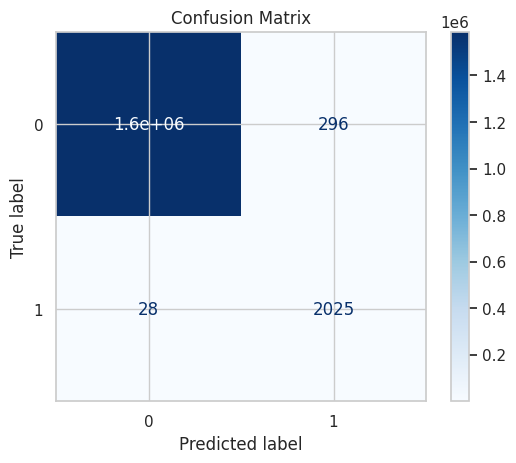

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
##______Model Evaluation & Visualization______

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    auc
)

In [ ]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.87      0.99      0.93      2053

    accuracy                           1.00   1590655
   macro avg       0.94      0.99      0.96   1590655
weighted avg       1.00      1.00      1.00   1590655



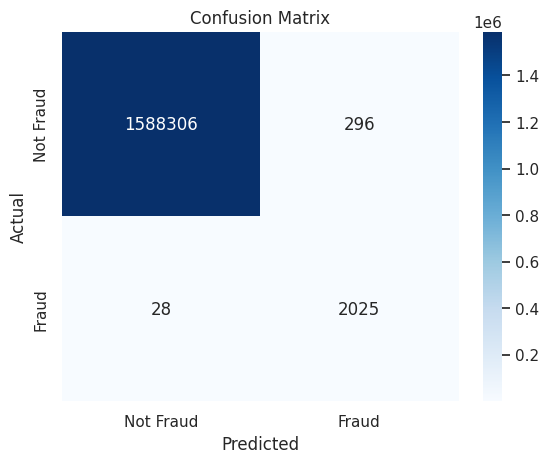

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ROC-AUC Score
roc_score = roc_auc_score(y_test, y_pred_proba)
print(f"📈 ROC-AUC Score: {roc_score:.4f}")

📈 ROC-AUC Score: 0.9999


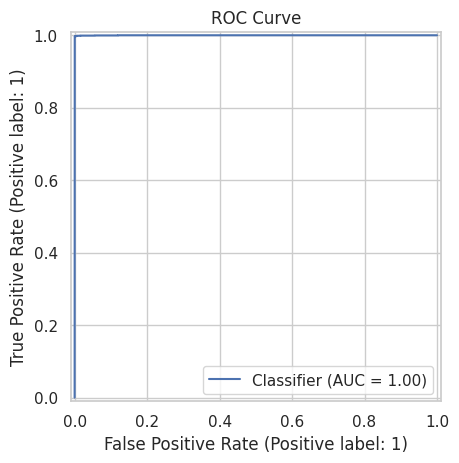

In [ ]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("ROC Curve")
plt.show()

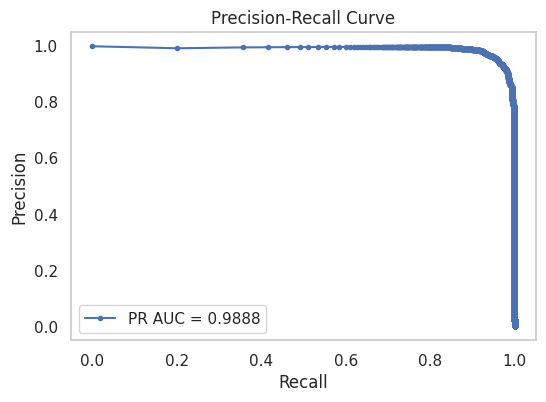

In [ ]:
# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.show()

In [ ]:
##______LightGBM_______

In [ ]:
pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:

# Initialize LightGBM classifier
lgb_model = LGBMClassifier(
    class_weight='balanced',  # handle class imbalance
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7
)

# Train the model
lgb_model.fit(X_train, y_train)

# Predict
y_pred = lgb_model.predict(X_test)
y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]  # For AUC/PR curves

[LightGBM] [Info] Number of positive: 6160, number of negative: 4765805
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.578904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2140
[LightGBM] [Info] Number of data points in the train set: 4771965, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1588602
           1       0.97      1.00      0.98      2053

    accuracy                           1.00   1590655
   macro avg       0.98      1.00      0.99   1590655
weighted avg       1.00      1.00      1.00   1590655



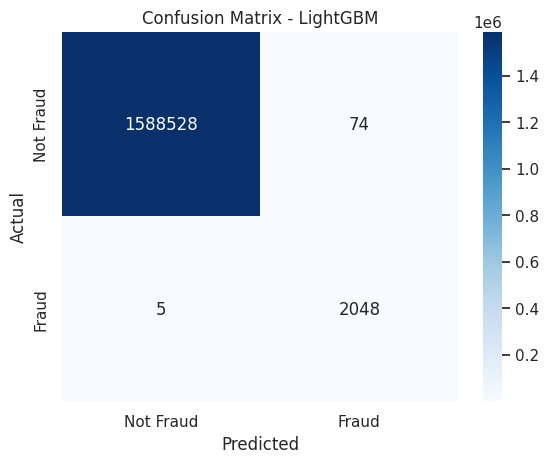

📈 ROC-AUC Score: 0.9999


In [ ]:
# Classification metrics
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"📈 ROC-AUC Score: {auc_score:.4f}")

In [ ]:
import joblib
joblib.dump(lgb_model, 'lightgbm_fraud_model.pkl')
print("LightGBM model saved as 'lightgbm_fraud_model.pkl'")


LightGBM model saved as 'lightgbm_fraud_model.pkl'


In [ ]:
pip install secure-smtplib

In [ ]:
##_______Email Alert Function After Prediction ________

In [ ]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

In [ ]:
def send_alert_email(transaction_info, triggered_by="Model", to_email=None):
    sender_email = os.getenv("EMAIL_USER")
    sender_password = os.getenv("EMAIL_PASS")
    subject = "Fraud Alert Detected!"
    body = f"""
    A potential fraudulent transaction has been detected by: {triggered_by}

    Transaction Details:
    ---------------------
    {transaction_info}
    """

    message = MIMEMultipart()
    message["From"] = sender_email
    message["To"] = to_email
    message["Subject"] = subject
    message.attach(MIMEText(body, "plain"))

    try:
        server = smtplib.SMTP("smtp.gmail.com", 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(message)
        server.quit()
        print(f"Email sent for alert by {triggered_by}")
    except Exception as e:
        print(f"Failed to send email: {e}")

In [ ]:
import numpy as np
import os # Import the os module

xgb_preds = xgb_model.predict(X_test)
lgb_preds = lgb_model.predict(X_test)
combined_preds = np.where((xgb_preds==1) | (lgb_preds==1), 1, 0)

# Map back to original DataFrame indices
df_test = df.iloc[y_test.index].reset_index(drop=True)
X_test_df = pd.DataFrame(X_test, columns=X.columns)  # for context

for idx, pred in enumerate(combined_preds):
    if pred == 1:
        triggered_by = []
        if xgb_preds[idx] == 1: triggered_by.append("XGBoost")
        if lgb_preds[idx] == 1: triggered_by.append("LightGBM")
        model_names = ", ".join(triggered_by)

        trans_info = df_test.iloc[idx].to_string()
        send_alert_email(transaction_info=trans_info, triggered_by=model_names, to_email=os.getenv("ALERT_EMAIL"))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to send email: 'NoneType' object has no attribute 'encode'
Failed to 

In [ ]:
!pip install streamlit